# Center-grating analysis

This notebook analyzes `spotWithAnnularGrating` with the grating restricted to the
**center**. It follows the same workflow as the cone center/annulus notebooks:
database refresh, condition discovery, one-cell analysis, persistent saving,
population analysis, and an example-stimulus visualization.

The light level is reconstructed per epoch block. Fixed `EL...` filters come from
the raw Stage device configurator; embedded `FW...` text there is ignored. The
numeric FilterWheel reading comes independently from protected metadata and must
agree across every epoch in a block. The resulting maximum is the calibrated R*/s
at normalized display intensity 1; the actual background is
`max_light_level × backgroundIntensity`.


In [1]:
import sys
import time

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')

import_started = time.perf_counter()
import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_grating as sag

SITE = 'center'
SITE_LABEL = 'Center-grating analysis'
MAX_SERIES_RESISTANCE = 30e6
STORE_PATH = sag.store_dir() / f'{SITE}_grating'

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')
print(f'Saved records: {STORE_PATH}')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.60 s
Saved records: /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_grating/center_grating


## 1. Load or refresh the single-cell database

Set `UPDATE_DATABASE = True` when new Symphony H5/JSON metadata should be ingested.
The default connects to the existing local DataJoint database without changing it.


In [2]:
UPDATE_DATABASE = False
ra.djconnect()

if UPDATE_DATABASE:
    database_report = ra.populate_database()
    print(f"newly added: {len(database_report['added'])}")
    print(f"refreshed: {len(database_report['updated'])}")
    print(f"errored: {len(database_report['skipped'])}")
    print(f"database: {len(database_report['experiments'])} experiments; "
          f"{len(database_report['stale'])} still out of date")
else:
    print('Connected to the existing database. Set UPDATE_DATABASE=True to ingest changes.')


Connected to the existing database. Set UPDATE_DATABASE=True to ingest changes.


## 2. Search the database for center-grating recordings

Discovery keeps every recorded cell type, numeric FilterWheel setting, bright-bar
contrast, and bar width. Series resistance still resolves and validates
`onlineAnalysis`. Each row is one explicit cell × mode × NDF combination ×
background × bright contrast × bar-width condition, although the compact table
omits the bright-contrast and database bookkeeping columns requested for this view.

`ndf_combination` and `max_light_level` come from the block-level light reader; no
protocol `maxIntensity` parameter is assumed. `date_index` uses the complete sorted
protocol date list, so the same value works in Section 3 even when a date has no
recording for this grating site.

In [6]:
protocol_index = sc.find_blocks(sag.PROTOCOL, show=False)
protocol_dates = sorted(protocol_index.exp_name.dropna().unique())
date_index_map = {exp_name: index + 1 for index, exp_name in enumerate(protocol_dates)}

df_blocks = sag.find_blocks(show=False)
df_blocks = sag.check_series_resistance(
    df_blocks, max_series_resistance=MAX_SERIES_RESISTANCE)
site_blocks = df_blocks[df_blocks.grating_site.eq(SITE)].copy()

selected = sag.group_blocks(
    site_blocks, show=False,
    require_filter_wheel=False,
    allowed_bright_contrast=None,
    min_bar_width=None,
    min_epochs=None,
    separate_bright_contrast=True,
    collapse_bar_widths=False)
selected = selected.sort_values(
    ['exp_name', 'cell_label', 'onlineAnalysis', 'ndf_combination',
     'backgroundIntensity', 'bright', 'bar_width']).reset_index(drop=True)
selected.insert(0, 'date_index', selected.exp_name.map(date_index_map).astype(int))

print(f'{SITE_LABEL}: {len(selected)} conditions across '
      f'{selected.exp_name.nunique()} experiments and '
      f"{selected.groupby(['exp_name', 'cell_label']).ngroups} cells")
condition_columns = [
    'date_index', 'exp_name', 'cell_label', 'cell_type_short', 'onlineAnalysis',
    'ndf_combination', 'filter_wheel_ndf', 'max_light_level',
    'backgroundIntensity', 'spot_intensity', 'bar_width', 'aperture',
    'annulus_inner', 'annulus_outer',
]
condition_columns = [column for column in condition_columns if column in selected]
sc.scroll_table(
    selected[condition_columns], height=430,
    num_cols=('date_index', 'filter_wheel_ndf', 'max_light_level',
              'backgroundIntensity', 'spot_intensity', 'bar_width', 'aperture',
              'annulus_inner', 'annulus_outer'))

  2026-01-02_E_2: cannot open the h5 (FileNotFoundError) — 2 block(s) have no series-resistance reading
reading the trace for 23 block(s) whose mode the label does not settle (0 never labelled, 23 contradicted)
series resistance read for 231/233 blocks

onlineAnalysis vs the amplifier (as recorded, before any relabelling)
series resistance says  (no reading)  cell-attached  whole-cell
onlineAnalysis says                                            
cell-attached                      0            178           2
whole-cell                         2             31          20

33 block(s) where the amplifier disagrees:
      exp_name cell_label cell_type_short      recorded   analyzed as  Rs (MOhm)  n_epochs  block_id                                                                                                                                  rs_flag
  2025-10-15_E      Cell6      ON-parasol           exc extracellular       0.00        33     18847                                      

date_index,exp_name,cell_label,cell_type_short,onlineAnalysis,ndf_combination,filter_wheel_ndf,max_light_level,backgroundIntensity,spot_intensity,bar_width,aperture,annulus_inner,annulus_outer
2,2025-10-22_E,Cell2,bipolar,extracellular,EL3 + FW0,0.0,30000.0,0.3,0.3,100.0,0.0,0.0,1200.0
2,2025-10-22_E,Cell5,horizontal,exc,EL3 + FW0,0.0,30000.0,0.3,0.3,100.0,0.0,0.0,1200.0
2,2025-10-22_E,Cell5,horizontal,exc,EL3 + FW0,0.0,30000.0,0.5,0.5,100.0,0.0,0.0,1200.0
4,2025-11-12_E,Cell3,horizontal,exc,EL3 + FW0,0.0,30000.0,0.3,0.3,100.0,0.0,0.0,1200.0
10,2026-02-26_E,Cell1,OFF-parasol,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.0,50.0,0.0,0.0,300.0
10,2026-02-26_E,Cell5,OFF-parasol,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.0,50.0,0.0,0.0,300.0
10,2026-02-26_E,Cell5,OFF-parasol,extracellular,EL3 + FW0,0.0,30000.0,0.5,0.0,75.0,0.0,0.0,400.0
11,2026-03-03_E,Cell7,horizontal,exc,FW0,0.0,30000000.0,0.5,0.0,75.0,0.0,0.0,1200.0
12,2026-03-03_E_2,Cell7,horizontal,exc,FW0,0.0,30000000.0,0.5,0.0,75.0,0.0,0.0,1200.0
13,2026-03-09_E,Cell3,horizontal,exc,EL3 + FW0,0.0,30000.0,0.5,0.0,75.0,0.0,0.0,1200.0


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:430px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>onlineAnalysis</th><th>ndf_combination</th><th>filter_wheel_ndf</th><th>max_light_level</th><th>backgroundIntensity</th><th>spot_intensity

## 3. Analyze one cell across its recorded conditions

Enter a `date_index`, cell label, and resolved `onlineAnalysis`; no background or
NDF selection is required. This standalone section finds every matching condition
and prints a condition table when there is more than one. Each unique fixed-NDF +
FilterWheel combination, background intensity, and bright-bar contrast is analyzed
separately.

If more than one bright-bar contrast or bar width was recorded, an alert is printed. With
`COLLAPSE_BAR_WIDTHS = False` (the default), each width is also analyzed and saved as
a separate condition. Set it to `True` only when you deliberately want to pool all
bar widths within each otherwise-identical condition.

When multiple fixed-NDF + FilterWheel + background combinations are present,
their tuning curves are overlaid after the individual condition plots. The overlay
labels retain bright-bar contrast and bar width so any additional stimulus changes
remain visible.

Section 3 delegates discovery, analysis, metadata display, and plotting to
`sag.analyze_cell_conditions`, leaving only explicit controls in the notebook.
`DETECTOR_KWARGS` applies center-grating-only detector overrides: candidates from
all epochs in a block are clustered together with one shared polarity and cluster
boundary, plus a minimum peak amplitude of 10. The 5 s trial-section limit remains
configured for the per-epoch fallback; the pooled fit is intentionally not split.
This keeps small neighboring-cell events from becoming the apparent spike cluster in epochs
that contain no large spikes from the recorded cell.
`SPIKE_OFFSET_MS` and `WC_OFFSET_MS` visibly control how far after stimulus
onset each response window starts. Spike counting starts at 0 ms, while the
whole-cell offset remains 100 ms; both windows still stop at `preTime +
stimTime`. Extracellular responses then subtract the firing rate measured
before `preTime`.
Whole-cell tuning curves remain baseline-subtracted.

Before traces are loaded, each condition prints cell identity and time, stimulus
parameters, light calibration, block IDs, and epoch count. Series resistance remains
part of the analysis/QC even though it is omitted from the compact Section 2 table.

ALERT: 2 unique conditions found; each will be analyzed separately:


,condition_index,ndf_combination,filter_wheel_ndf,backgroundIntensity,bright,bar_width,max_light_level,rstar,blocks,epochs,block_ids
0,1,EL3 + FW0,0.0,0.5,0.9,100.0,30000.0,15000.0,2,88,"34292, 34296"
1,2,EL3 + FW1,1.0,0.5,0.9,100.0,3000.0,1500.0,1,43,34293


ALERT: 2 NDF/FilterWheel/background combinations found; each becomes a separate saved entry and their tuning curves will be overlaid.
Condition 1/2 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spikeOffset_ms,wholeCellOffset_ms,spotIntensity,brightBarContrast,barWidth_um,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s
0,1,Cell6,OFF-parasol,extracellular,0.0,30.0,0.0,0.9,100.0,0.0,0.0,500.0,15000.0


2026-04-23_E | RGC\OFF-parasol | Cell6 | extracellular | grating center | EL3 + FW0, max=30000R*/s bg=0.50 (15000R*) | 88 epochs  Rs=0 (cell-attached)  offset=0 ms
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response − baseline: [43.011 40.511 37.386 31.761 19.886  6.136  1.136 -0.739 -1.364 -0.114
 -0.739]
  baseline=1.364 | crossing nearest=-0.100 interp=-0.339 | cone pred=-0.348
Condition 2/2 metadata:


,condition_index,cell_label,cell_type,onlineAnalysis,spikeOffset_ms,wholeCellOffset_ms,spotIntensity,brightBarContrast,barWidth_um,apertureDiameter_um,annulusInnerDiameter_um,annulusOuterDiameter_um,background_Rstar_per_s
0,2,Cell6,OFF-parasol,extracellular,0.0,30.0,0.0,0.9,100.0,0.0,0.0,500.0,1500.0


2026-04-23_E | RGC\OFF-parasol | Cell6 | extracellular | grating center | EL3 + FW1, max=3000R*/s bg=0.50 (2000R*) | 43 epochs  Rs=0 (cell-attached)  offset=0 ms
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response − baseline: [44.622 40.872 37.122 24.622 12.122  3.372  3.372 -0.378 -0.378 -1.628
  0.872]
  baseline=1.628 | crossing nearest=-0.300 interp=-0.310 | cone pred=-0.508
Overlaying baseline-subtracted tuning curves across the recorded light conditions.
Analyzed 2 separate condition(s) for 2026-04-23_E Cell6.


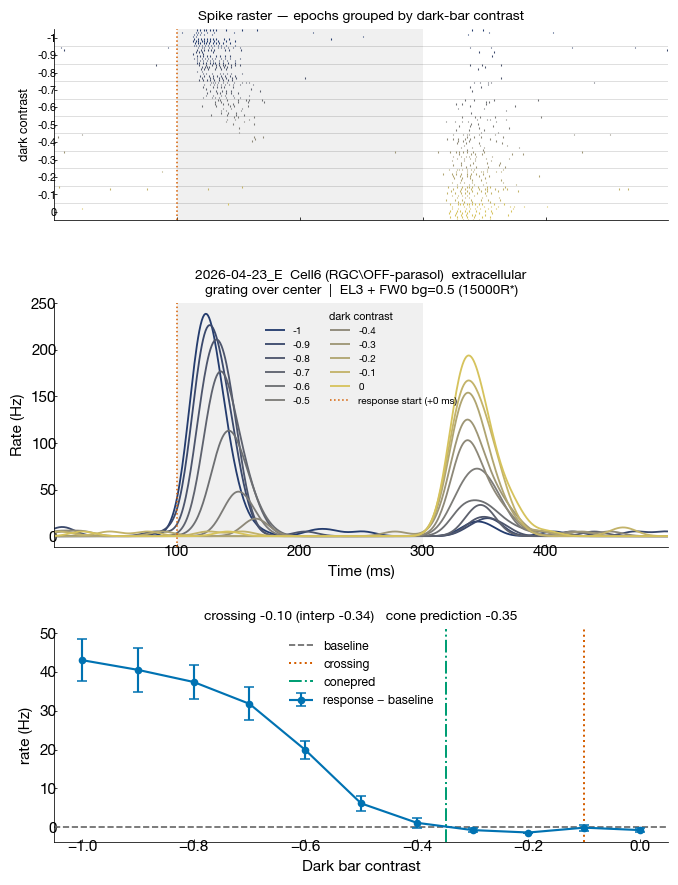

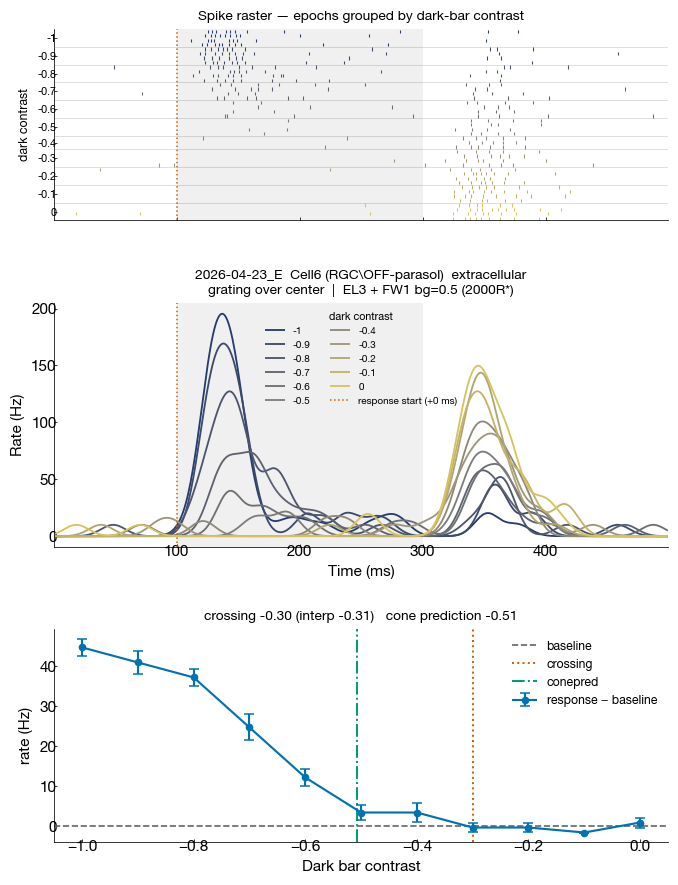

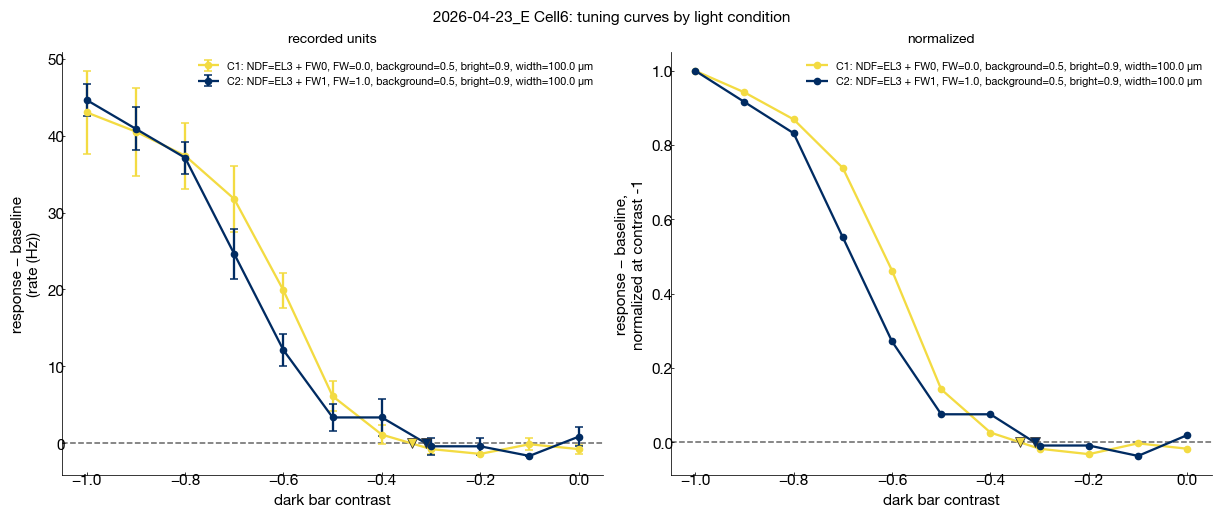

In [2]:
# Standalone after the import cell; Section 2 is optional.
DATE_INDEX = 20
CELL_LABEL = 'Cell6'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
COLLAPSE_BAR_WIDTHS = False
SPIKE_OFFSET_MS = 0.0
WC_OFFSET_MS = 30.0
DETECTOR_KWARGS = {
    'min_peak_amplitude': 10.0,
    'max_trial_length_s': 2.0,
    'cluster_across_trials': True,
    'global_polarity': True,
}

section3 = sag.analyze_cell_conditions(
    date_index=DATE_INDEX,
    cell_label=CELL_LABEL,
    online_analysis=ONLINE_ANALYSIS,
    site=SITE,
    collapse_bar_widths=COLLAPSE_BAR_WIDTHS,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    spike_offset=SPIKE_OFFSET_MS,
    wc_offset=WC_OFFSET_MS,
    detector_kwargs=DETECTOR_KWARGS,
    keep_raw=True,
    plot=True,
    show=True)

# Short aliases retained for Sections 3a and 5.
EXP_NAME = section3.exp_name
condition_rows = section3.condition_rows
light_conditions = section3.light_conditions
records = section3.records
condition_figures = section3.condition_figures
light_tuning_figure = section3.light_tuning_figure


### 3a. Check spike detection on a random subset of epochs

For extracellular recordings, plot raw amplifier traces with detected spikes marked.
This optional check is disabled by default; set `RUN_SPIKE_DETECTION_QC = True`
to run it. `SPIKE_QC_FRACTION` controls the sampled fraction (default 30%), and
`SPIKE_QC_RANDOM_SEED` makes the selection reproducible; set it to `None` to draw a
new random subset each run. Sampling occurs separately within every analyzed light
condition. Use the `QC view` pull-down to inspect one sampled epoch at a time without
stacking every trace vertically. The general `ra.plot_spike_detection_qc` utility accepts traces and spike
times from any protocol notebook.

In [ ]:
RUN_SPIKE_DETECTION_QC = True
SPIKE_QC_FRACTION = 0.30
SPIKE_QC_RANDOM_SEED = 0  # Set to None for a new random subset each run.
SPIKE_QC_EPOCHS_PER_VIEW = 1  # Keep each pull-down view compact.

if RUN_SPIKE_DETECTION_QC and not records:
    raise ValueError('Run Section 3 before checking spike detection')

import ipywidgets as widgets
spike_detection_qc = {}
spike_qc_options = []
seen_spike_qc_epochs = set()
for condition_index, record in enumerate(
        records if RUN_SPIKE_DETECTION_QC else [], start=1):
    if record.online_analysis != 'extracellular':
        continue
    if record.raw is None or not record.raw.get('traces'):
        print(f'Condition {condition_index}: no raw traces; rerun Section 3 with keep_raw=True.')
        continue

    condition_seed = (None if SPIKE_QC_RANDOM_SEED is None
                      else int(SPIKE_QC_RANDOM_SEED) + condition_index - 1)
    figures, selected_epochs = ra.plot_spike_detection_qc(
        record.raw['traces'],
        record.raw['spike_times_ms'],
        sample_rate=record.raw['sample_rate'],
        fraction=SPIKE_QC_FRACTION,
        random_state=condition_seed,
        spike_time_unit='ms',
        stimulus_window_ms=(record.pre_time_ms, record.pre_time_ms + record.stim_time_ms),
        max_epochs_per_figure=SPIKE_QC_EPOCHS_PER_VIEW,
        close_figures=True,
        title=(f'Condition {condition_index}: {record.exp_name} | {record.cell_label} | '
               f'{record.config.get("ndf_combination", "")}'))
    spike_detection_qc[condition_index] = {
        'figures': figures,
        'selected_epochs': selected_epochs,
    }
    raw_block_ids = record.raw.get('block_id', [])
    raw_epoch_indices = record.raw.get('epoch_index', [])
    for view_index, figure in enumerate(figures):
        # Closed figures do not stack in notebook output; the selected one is
        # explicitly rendered by the pull-down callback below.
        start = view_index * SPIKE_QC_EPOCHS_PER_VIEW
        view_epochs = selected_epochs[start:start + SPIKE_QC_EPOCHS_PER_VIEW]
        local_epoch = int(view_epochs[0])
        if local_epoch < len(raw_block_ids):
            block_id = int(raw_block_ids[local_epoch])
            epoch_in_block = (int(raw_epoch_indices[local_epoch])
                              if local_epoch < len(raw_epoch_indices)
                              else sum(int(value) == block_id
                                       for value in raw_block_ids[:local_epoch]))
            source_key = (record.exp_name, block_id, epoch_in_block)
            epoch_label = f'block {block_id} | epoch {epoch_in_block}'
            figure.axes[0].set_ylabel(f'Block {block_id}\nEpoch {epoch_in_block}')
        else:
            source_key = (record.exp_name, condition_index, local_epoch)
            epoch_label = f'local epoch {local_epoch}'
        if source_key in seen_spike_qc_epochs:
            continue
        seen_spike_qc_epochs.add(source_key)
        spike_qc_options.append((
            f'Condition {condition_index} | {epoch_label}',
            (condition_index, view_index)))
    print(f'Condition {condition_index}: checking epochs {selected_epochs.tolist()}')

if not RUN_SPIKE_DETECTION_QC:
    print('Spike-detection QC skipped. Set RUN_SPIKE_DETECTION_QC = True to enable it.')
elif not spike_detection_qc:
    print('No extracellular records are available for spike-detection QC.')
else:
    spike_qc_selector = widgets.Dropdown(
        options=spike_qc_options,
        description='QC view:',
        layout=widgets.Layout(width='520px'),
        style={'description_width': '70px'})
    spike_qc_output = widgets.Output()

    def _show_spike_qc(change=None):
        condition_index, view_index = spike_qc_selector.value
        figure = spike_detection_qc[condition_index]['figures'][view_index]
        spike_qc_output.clear_output(wait=False)
        with spike_qc_output:
            display(figure)

    spike_qc_selector.observe(_show_spike_qc, names='value')
    spike_detection_qc_browser = widgets.VBox([spike_qc_selector, spike_qc_output])
    display(spike_detection_qc_browser)
    _show_spike_qc()

/Users/chrischen/Documents/GitHub/retinanalysis/src/retinanalysis/utils/spike_detection_qc.py:81: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


Condition 1: checking epochs [0, 1, 2, 5, 12, 17, 20, 22, 32, 33, 37, 40, 42, 44, 45, 46, 48, 49, 52, 56, 57, 66, 67, 73, 74, 75, 83]
Condition 2: checking epochs [1, 5, 9, 11, 12, 14, 16, 17, 24, 30, 32, 35, 36]


### 3b. Save these conditions for population analysis

Save every analyzed condition to the site-specific HDF5 store. The key includes
date, cell, mode, site, fixed NDFs, numeric FilterWheel, background, bright-bar
contrast, and the analyzed bar-width set. Therefore multiple light/background/bar
conditions from the same cell remain separate entries; rerunning an identical
condition replaces only that entry.

In [4]:
if not records:
    raise ValueError('Run Section 3 before saving')
condition_output_path = sag.save_records(records, path=STORE_PATH)
print(f'Saved {len(records)} separate condition(s) to {condition_output_path}')

  added 2026-04-23_E__Cell6__extracellular__center__FW0__bg0p5__EL3-FW0__bright0p9__bar100
  added 2026-04-23_E__Cell6__extracellular__center__FW1__bg0p5__EL3-FW1__bright0p9__bar100
2 record(s) saved -> /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_grating/center_grating/records.h5 (12 rows total)
Saved 2 separate condition(s) to /Volumes/ChrisNewSSD/retinanalysis_output/spot_annular_grating/center_grating/records.h5


### 3c. Check saved conditions

Load only the scalar index. Every NDF/background/bright/bar-width condition is one
row; trace arrays remain on disk until a plot requests them.

In [5]:
saved_cells = sag.load_summary(path=STORE_PATH)
saved_columns = [
    'exp_name', 'cell_label', 'cell_type', 'online_analysis', 'ndf_combination',
    'max_light_level', 'background_intensity', 'bright_bar_contrast',
    'bar_widths', 'rstar', 'series_resistance', 'n_epochs_high_rs',
    'n_epochs', 'block_ids',
]
saved_columns = [column for column in saved_columns if column in saved_cells]
print(f'{len(saved_cells)} saved {SITE}-grating condition(s)')
sc.scroll_table(
    saved_cells[saved_columns], height=320,
    num_cols=('max_light_level', 'background_intensity', 'bright_bar_contrast',
              'rstar', 'series_resistance', 'n_epochs_high_rs', 'n_epochs'))

8 saved center-grating condition(s)


exp_name,cell_label,cell_type,online_analysis,ndf_combination,max_light_level,background_intensity,bright_bar_contrast,bar_widths,rstar,series_resistance,n_epochs_high_rs,n_epochs,block_ids
2026-04-14_E,Cell1,RGC\OFF-parasol,extracellular,EL3 + FW0,30000.0,0.5,0.9,75,15000.0,0.0,0,77,"33999,34002"
2026-04-14_E,Cell1,RGC\OFF-parasol,extracellular,EL3 + FW1,3000.0,0.5,0.9,75,1500.0,0.0,0,88,"34000,34001"
2026-04-14_E,Cell3,RGC\OFF-parasol,exc,EL3 + FW0,30000.0,0.5,0.9,75,15000.0,24914972.712172743,0,44,34037
2026-04-14_E,Cell3,RGC\OFF-parasol,exc,EL3 + FW1,3000.0,0.5,0.9,75,1500.0,24914972.712172743,0,44,34038
2026-04-14_E,Cell3,RGC\OFF-parasol,extracellular,EL3 + FW0,30000.0,0.5,0.9,75,15000.0,0.0,0,88,"34027,34029"
2026-04-14_E,Cell3,RGC\OFF-parasol,extracellular,EL3 + FW1,3000.0,0.5,0.9,75,1500.0,0.0,0,44,34028
2026-04-23_E,Cell2,RGC\OFF-parasol,extracellular,EL3 + FW0,30000.0,0.5,0.9,75,15000.0,0.0,0,33,34321
2026-04-23_E,Cell2,RGC\OFF-parasol,extracellular,EL3 + FW1,3000.0,0.5,0.9,75,1500.0,0.0,0,66,"34322,34323"


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:320px"><table><thead><tr><th>exp_name</th><th>cell_label</th><th>cell_type</th><th>online_analysis</th><th>ndf_combination</th><th>max_light_level</th><th>background_intensity</th><th>bright_bar_contrast</th><th>bar_widths</th><th>rstar</th><th>s

## 4. Population analysis

Population work includes every saved cell type. Conditions are labelled as
`cell type / grating site`, and recording modes remain separate because firing rate
and current have different units. Bright-bar contrasts are plotted in separate figure
sets so their different cone predictions are never mixed.

In [ ]:
summary = sag.add_condition(sag.load_summary(path=STORE_PATH))
if summary.empty:
    raise ValueError(f'No saved {SITE}-grating records in {STORE_PATH}')

population_table = (summary.groupby(
    ['cell_type_short', 'online_analysis', 'ndf_combination',
     'background_intensity', 'bright_bar_contrast', 'bar_widths', 'rstar_level'],
    dropna=False)
    .agg(recordings=('key', 'size'), cells=('cell_label', 'nunique'),
         epochs=('n_epochs', 'sum'), mean_rstar=('rstar', 'mean'),
         crossing_mean=('crossing_interp', 'mean'),
         crossing_sem=('crossing_interp', 'sem'))
    .reset_index())
sc.scroll_table(
    population_table, height=320,
    num_cols=('background_intensity', 'bright_bar_contrast', 'rstar_level',
              'recordings', 'cells', 'epochs', 'mean_rstar',
              'crossing_mean', 'crossing_sem'))

bright_values = sorted(summary.bright_bar_contrast.dropna().astype(float).unique())
for bright_value in bright_values:
    bright_summary = summary[np.isclose(summary.bright_bar_contrast, bright_value)].copy()
    available_conditions = tuple(bright_summary.condition.dropna().drop_duplicates())
    available_modes = tuple(bright_summary.online_analysis.dropna().drop_duplicates())
    print(f'Population figures: brightBarContrast={bright_value:g}; '
          f'{len(bright_summary)} saved conditions')
    sag.plot_weber_comparison(
        bright_summary, bright_contrast=bright_value,
        conditions=available_conditions, modes=available_modes)
    sag.plot_population_tuning(
        bright_summary, conditions=available_conditions, modes=available_modes,
        allowed_bright_contrast=None)

### 4a. Example saved recording from each cell-type/site and mode

For each bright-bar contrast, show the most deeply sampled saved recording from
every available cell-type/site condition and recording mode.

In [ ]:
all_records = sag.load_records(path=STORE_PATH)
for bright_value in bright_values:
    bright_summary = summary[np.isclose(summary.bright_bar_contrast, bright_value)].copy()
    available_conditions = tuple(bright_summary.condition.dropna().drop_duplicates())
    available_modes = tuple(bright_summary.online_analysis.dropna().drop_duplicates())
    bright_keys = set(bright_summary.key)
    bright_records = {key: value for key, value in all_records.items() if key in bright_keys}
    print(f'Examples: brightBarContrast={bright_value:g}')
    sag.plot_condition_examples(
        bright_records, conditions=available_conditions, modes=available_modes)

## 5. Example center-grating stimulus

Render the selected block using the recorded aperture, annulus, bar width,
background, spot intensity, and bright/dark contrasts. The geometry should visibly
place the grating over the **center**; the center spot remains an independent protocol
parameter for surround recordings.


In [ ]:
EXAMPLE_CONDITION_INDEX = 1
if not 1 <= EXAMPLE_CONDITION_INDEX <= len(records):
    raise ValueError(f'EXAMPLE_CONDITION_INDEX must be 1-{len(records)}')
example_record = records[EXAMPLE_CONDITION_INDEX - 1]
example_block = int(example_record.block_ids[0])
stim = ra.StimBlock(example_record.exp_name, example_block, verbose=False)
example_parameters = stim.df_epochs['epoch_parameters'].iloc[0]
dark_values = np.sort(stim.df_epochs['currentDarkContrast'].dropna().unique())
example_dark = dark_values[[0, len(dark_values) // 2, -1]]
stimulus_figure = sag.plot_stimulus_schematic(
    example_parameters, dark_contrasts=example_dark)